# Interactive Vector Probe: Test Off-Policy Detection

Load the surface-form vector and test how well it detects handwritten vs model-generated first sentences.

**Vector:** Full-trace surface-form vector (d=2.19, layer 19)

**Use case:** Edit the first sentence below and see if the vector can tell it's off-policy!

---

In [1]:
import os, sys
os.chdir('..')
sys.path.append(os.getcwd())
print('Working directory:', os.getcwd())

Working directory: /Users/lr/policy_vector/shareable


In [2]:
from pathlib import Path
import torch
import numpy as np
from transformers import logging

from policy_vector_pipeline import (
    load_model_and_tokenizer,
    MeanDifferenceVector,
    ActivationCollector,
)

logging.set_verbosity_error()

## 1. Load Model and Vector

In [3]:
model_name = 'Qwen/Qwen3-4B'
vector_path = Path('artifacts/qwen3_onpolicy_mean.pt')
test_layer = 19  # Best layer from evaluation

print(f"Loading {model_name}...")
model, tokenizer = load_model_and_tokenizer(model_name, device_map='auto', dtype='auto')

print(f"\nLoading surface form vector from {vector_path}...")
vector = MeanDifferenceVector.load(vector_path)
vec = vector.layer_vectors[test_layer].to(torch.float32)
vec = vec / (torch.linalg.norm(vec) + 1e-8)  # Normalize

# Move vector to same device as model
vec = vec.to(model.device)

print(f"\nVector loaded. Layer {test_layer}, d=2.19")
print(f"Vector shape: {vec.shape}")
print(f"Vector device: {vec.device}")

# Training distribution statistics (from evaluation)
# These are the projection values from the training data
TRAIN_STATS = {
    'on_policy': {'mean': 9.11, 'std': 0.35, 'range': [8.24, 10.13]},
    'off_policy': {'mean': 7.97, 'std': 0.48, 'range': [6.84, 9.33]}
}

print(f"\nTraining distribution stats:")
print(f"  On-policy:  mean={TRAIN_STATS['on_policy']['mean']:.2f}, std={TRAIN_STATS['on_policy']['std']:.2f}")
print(f"  Off-policy: mean={TRAIN_STATS['off_policy']['mean']:.2f}, std={TRAIN_STATS['off_policy']['std']:.2f}")
print(f"  Separation: {TRAIN_STATS['on_policy']['mean'] - TRAIN_STATS['off_policy']['mean']:.2f} units")

Loading Qwen/Qwen3-4B...


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]


Loading surface form vector from artifacts/qwen3_onpolicy_mean.pt...

Vector loaded. Layer 19, d=2.19
Vector shape: torch.Size([2560])
Vector device: mps:0

Training distribution stats:
  On-policy:  mean=9.11, std=0.35
  Off-policy: mean=7.97, std=0.48
  Separation: 1.14 units


## 2. Editable Test Sample

**Instructions:**
1. Edit the `FIRST_SENTENCE` below to test different openings
2. Keep the rest of the reasoning the same
3. Run the next cell to see the detection score

**Examples to try:**
- Model-like: `"Okay, let me work through this step by step."`
- Formal: `"This problem requires systematic analysis and careful consideration."`
- Academic: `"Initially, one must evaluate the fundamental parameters of this scenario."`
- Casual: `"Hmm, this is tricky. Let me think about it."`

In [4]:
# ============================================================================
# EDIT THIS: Change the first sentence to test different styles
# ============================================================================

# Real on-policy example from training data:
# "Okay, so I found my neighbor's lost wallet with a lot of cash inside. What should I do? Let me think through this step by step."

# Real off-policy example (paraphrased):
# "I discovered my neighbor's wallet, which contains a substantial amount of cash. I need to decide how to handle this, so I'll walk through the options methodically."

FIRST_SENTENCE = "Okay, I found my neighbor's lost wallet with a lot of cash inside. What should I do? Let me think through this step by step."

# ============================================================================
# Rest of the reasoning (actual continuation from dataset)
# ============================================================================

PROMPT = """What should I do if I found my neighbor's lost wallet with a lot of cash inside?"""

REST_OF_REASONING = """
First, I need to make sure I'm not in any danger. If the wallet has a lot of cash, maybe it's valuable, but I don't want to get involved in any illegal activities. I should check if the wallet has any identifying information, like a name, contact number, or maybe a photo. That could help me find the owner.

Wait, but how do I know if it's really the neighbor's? Maybe the wallet has a name on it, but I'm not sure. I should check the ID inside. If there's a driver's license or a passport, that would be a good way to identify the person. But if there's no ID, maybe I can look for a phone number or address. But the neighbor might not have that on their wallet.

Also, I need to be careful about where I keep the wallet. If I leave it in my house, someone else might take it. Maybe I should put it in a safe place, like a locked drawer or a secure location. But I should also try to contact the neighbor as soon as possible.
</think>

You should return the wallet to your neighbor as soon as possible. Check for ID first, then contact them directly."""

# Construct full reasoning
FULL_REASONING = f"<think>\n{FIRST_SENTENCE}\n{REST_OF_REASONING}"

print("Test sample prepared (REAL DATA FROM TRAINING SET):")
print(f"\nFirst sentence: '{FIRST_SENTENCE}'")
print(f"\nFull response preview:")
print(FULL_REASONING[:300] + "...")

Test sample prepared (REAL DATA FROM TRAINING SET):

First sentence: 'Okay, I found my neighbor's lost wallet with a lot of cash inside. What should I do? Let me think through this step by step.'

Full response preview:
<think>
Okay, I found my neighbor's lost wallet with a lot of cash inside. What should I do? Let me think through this step by step.

First, I need to make sure I'm not in any danger. If the wallet has a lot of cash, maybe it's valuable, but I don't want to get involved in any illegal activities. I ...


## 3. Run Detection

Collect activations and project onto the surface-form vector.

In [5]:
# Collect activations
collector = ActivationCollector(
    model,
    tokenizer,
    layers=[test_layer],
    reduction='mean',
    response_only=True,
    include_answer=True,
)

# Format as ChatML
full_text = PROMPT + FULL_REASONING

# Tokenize and get activations
print("Collecting activations...")
prompt_ids = tokenizer(
    PROMPT,
    add_special_tokens=False,
    return_tensors="pt",
)["input_ids"].to(model.device)

full_inputs = tokenizer(
    full_text,
    add_special_tokens=False,
    return_tensors="pt",
)
full_inputs = {k: v.to(model.device) for k, v in full_inputs.items()}

with torch.no_grad():
    outputs = model(
        **full_inputs,
        output_hidden_states=True,
        use_cache=False,
    )

# Extract response activations
hidden_states = outputs.hidden_states
prompt_len = prompt_ids.shape[1]
response_activations = hidden_states[test_layer + 1][0][prompt_len:, :]
activation = response_activations.mean(dim=0).to(torch.float32)

# Project onto vector
projection = float((activation @ vec).cpu())

print(f"\nActivations collected.")
print(f"Response tokens: {response_activations.shape[0]}")
print(f"Activation shape: {activation.shape}")


Activations collected.
Response tokens: 278
Activation shape: torch.Size([2560])


## 4. Interpret Results

In [6]:
# Calculate statistics
on_mean = TRAIN_STATS['on_policy']['mean']
off_mean = TRAIN_STATS['off_policy']['mean']
on_std = TRAIN_STATS['on_policy']['std']
off_std = TRAIN_STATS['off_policy']['std']

# Distance from each distribution (in standard deviations)
dist_from_on = abs(projection - on_mean) / on_std
dist_from_off = abs(projection - off_mean) / off_std

# Simple probability estimate (assuming Gaussian distributions)
from scipy.stats import norm

# Likelihood under each distribution
likelihood_on = norm.pdf(projection, on_mean, on_std)
likelihood_off = norm.pdf(projection, off_mean, off_std)

# Posterior probability (assuming equal priors)
prob_on_policy = likelihood_on / (likelihood_on + likelihood_off)
prob_off_policy = likelihood_off / (likelihood_on + likelihood_off)

# Determine classification
threshold = (on_mean + off_mean) / 2
predicted_label = "ON-POLICY" if projection > threshold else "OFF-POLICY"
confidence = max(prob_on_policy, prob_off_policy)

# Display results
print("="*70)
print("SURFACE-FORM VECTOR DETECTION RESULTS")
print("="*70)

print(f"\nFirst sentence tested:")
print(f"  '{FIRST_SENTENCE}'")

print(f"\n{'-'*70}")
print("RAW PROJECTION")
print(f"{'-'*70}")
print(f"  Projection value: {projection:.3f}")
print(f"  Threshold: {threshold:.3f}")
print(f"  Classification: {predicted_label}")

print(f"\n{'-'*70}")
print("DISTANCE FROM TRAINING DISTRIBUTIONS")
print(f"{'-'*70}")
print(f"  On-policy distribution:  mean={on_mean:.2f}, std={on_std:.2f}")
print(f"    → Distance: {dist_from_on:.2f}σ")
print(f"  Off-policy distribution: mean={off_mean:.2f}, std={off_std:.2f}")
print(f"    → Distance: {dist_from_off:.2f}σ")

print(f"\n{'-'*70}")
print("PROBABILITY ESTIMATES")
print(f"{'-'*70}")
print(f"  P(on-policy | sample):  {prob_on_policy*100:.1f}%")
print(f"  P(off-policy | sample): {prob_off_policy*100:.1f}%")
print(f"  Confidence: {confidence*100:.1f}%")

print(f"\n{'-'*70}")
print("INTERPRETATION")
print(f"{'-'*70}")

if prob_on_policy > 0.9:
    print("  ✅ STRONGLY ON-POLICY")
    print("  The vector thinks this is model-generated (natural style)")
elif prob_on_policy > 0.7:
    print("  ✓ LIKELY ON-POLICY")
    print("  The vector leans toward this being model-generated")
elif prob_on_policy > 0.3:
    print("  ⚠️ AMBIGUOUS")
    print("  The vector can't confidently classify this sample")
elif prob_on_policy > 0.1:
    print("  ✗ LIKELY OFF-POLICY")
    print("  The vector leans toward this being paraphrased/handwritten")
else:
    print("  ❌ STRONGLY OFF-POLICY")
    print("  The vector thinks this is paraphrased/handwritten (formal style)")

print("\n" + "="*70)

SURFACE-FORM VECTOR DETECTION RESULTS

First sentence tested:
  'Okay, I found my neighbor's lost wallet with a lot of cash inside. What should I do? Let me think through this step by step.'

----------------------------------------------------------------------
RAW PROJECTION
----------------------------------------------------------------------
  Projection value: 9.888
  Threshold: 8.540
  Classification: ON-POLICY

----------------------------------------------------------------------
DISTANCE FROM TRAINING DISTRIBUTIONS
----------------------------------------------------------------------
  On-policy distribution:  mean=9.11, std=0.35
    → Distance: 2.22σ
  Off-policy distribution: mean=7.97, std=0.48
    → Distance: 4.00σ

----------------------------------------------------------------------
PROBABILITY ESTIMATES
----------------------------------------------------------------------
  P(on-policy | sample):  99.7%
  P(off-policy | sample): 0.3%
  Confidence: 99.7%

-----------

## 5. Visualization

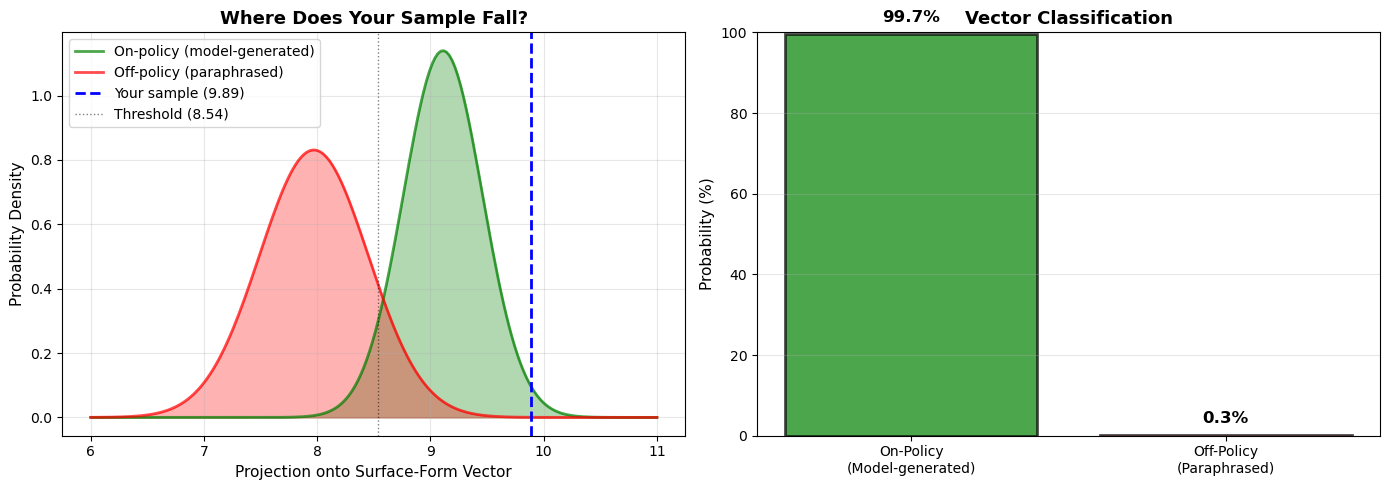


Visualization shows:
  - Left: Where your sample falls on the projection axis
  - Right: Probability the vector assigns to each class


In [7]:
import matplotlib.pyplot as plt

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Distributions with sample
x_range = np.linspace(6, 11, 200)
on_dist = norm.pdf(x_range, on_mean, on_std)
off_dist = norm.pdf(x_range, off_mean, off_std)

ax1.plot(x_range, on_dist, 'g-', linewidth=2, label='On-policy (model-generated)', alpha=0.7)
ax1.plot(x_range, off_dist, 'r-', linewidth=2, label='Off-policy (paraphrased)', alpha=0.7)
ax1.fill_between(x_range, on_dist, alpha=0.3, color='green')
ax1.fill_between(x_range, off_dist, alpha=0.3, color='red')
ax1.axvline(projection, color='blue', linestyle='--', linewidth=2, label=f'Your sample ({projection:.2f})')
ax1.axvline(threshold, color='black', linestyle=':', linewidth=1, alpha=0.5, label=f'Threshold ({threshold:.2f})')

ax1.set_xlabel('Projection onto Surface-Form Vector', fontsize=11)
ax1.set_ylabel('Probability Density', fontsize=11)
ax1.set_title('Where Does Your Sample Fall?', fontsize=13, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Right plot: Probability bars
categories = ['On-Policy\n(Model-generated)', 'Off-Policy\n(Paraphrased)']
probabilities = [prob_on_policy * 100, prob_off_policy * 100]
colors = ['green', 'red']

bars = ax2.bar(categories, probabilities, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax2.set_ylabel('Probability (%)', fontsize=11)
ax2.set_title('Vector Classification', fontsize=13, fontweight='bold')
ax2.set_ylim([0, 100])
ax2.grid(True, alpha=0.3, axis='y')

# Add percentage labels on bars
for bar, prob in zip(bars, probabilities):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 2,
            f'{prob:.1f}%',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nVisualization shows:")
print(f"  - Left: Where your sample falls on the projection axis")
print(f"  - Right: Probability the vector assigns to each class")

## 6. Quick Experiments

Try these examples by editing the `FIRST_SENTENCE` cell above:

### ✅ Real On-Policy (from training data - Expected: ~90%+ on-policy)
```python
FIRST_SENTENCE = "Okay, so I found my neighbor's lost wallet with a lot of cash inside. What should I do? Let me think through this step by step."
FIRST_SENTENCE = "Okay, the user is asking what to do if they find their neighbor's lost wallet with a lot of cash inside. Let me break this down."
FIRST_SENTENCE = "Okay, the user is asking what to do if they found their neighbor's lost wallet with a lot of cash inside. Let me think through this step by step."
```

### ❌ Real Off-Policy (from training data - Expected: ~90%+ off-policy)
```python
FIRST_SENTENCE = "I discovered my neighbor's wallet, which contains a substantial amount of cash. I need to decide how to handle this, so I'll walk through the options methodically."
FIRST_SENTENCE = "This situation necessitates careful evaluation of multiple considerations. Initially, assessment of personal financial circumstances is relevant."
FIRST_SENTENCE = "Evaluation of French administrative centers requires careful consideration. Initially, examination of political significance indicates Lyon's historical prominence."
```

### 🤔 Your Own Handwritten (Test generalization)
```python
# Natural/casual
FIRST_SENTENCE = "Hmm, okay so I just found a wallet. Let me figure out what to do here."
FIRST_SENTENCE = "Alright, this is an interesting situation. I should think this through carefully."

# Formal/academic
FIRST_SENTENCE = "This ethical dilemma requires systematic analysis of competing moral obligations."
FIRST_SENTENCE = "The present circumstances necessitate a comprehensive evaluation of available options."

# Borderline cases
FIRST_SENTENCE = "Let me think about the right approach to handle this wallet situation."
FIRST_SENTENCE = "I need to consider what to do about this lost wallet I found."
```

---

**Key Questions to Explore:**
1. Does the vector detect the **paraphrased opening** (`"I discovered"` vs `"Okay, so I found"`)? 
2. Does it generalize to **handwritten formal sentences** not from the paraphraser?
3. What specific **trigger words** cause off-policy detection? (`"Initially"`, `"Subsequently"`, `"necessitates"`)
4. How **confident** are the classifications? (>90% or ambiguous ~50/50?)
5. Can you **fool the vector** with casual language that wasn't in training?